In [7]:
#import dataset
from google.colab import files
uploaded = files.upload()

Saving ai4i2020.csv to ai4i2020 (1).csv


In [48]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [49]:
#Load Dataset
data = pd.read_csv("/content/ai4i2020.csv")
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [50]:
#Dataset Information
data.info()
data.isnull().sum()#check null values check

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [51]:
#Data Preprocessing
data = data.drop(["UDI","Product ID"], axis=1)#remove unnecessary columns
data["Type"] = data["Type"].map({"L":0,"M":1,"H":2})#convert categorical column
#clean column names
data.columns = data.columns.str.replace('[','')
data.columns = data.columns.str.replace(']','')
data.columns = data.columns.str.replace(' ','_')
#check column
data.columns

Index(['Type', 'Air_temperature_K', 'Process_temperature_K',
       'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure',
       'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

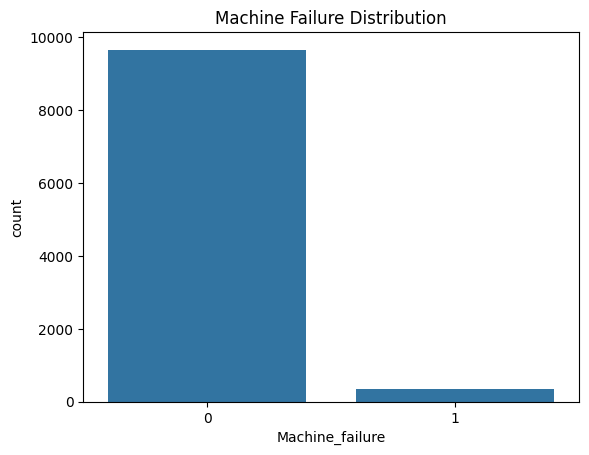

In [52]:
#Exploratory Data Analysis[EDA]
sns.countplot(x="Machine_failure", data=data)
plt.title("Machine Failure Distribution")
plt.show()

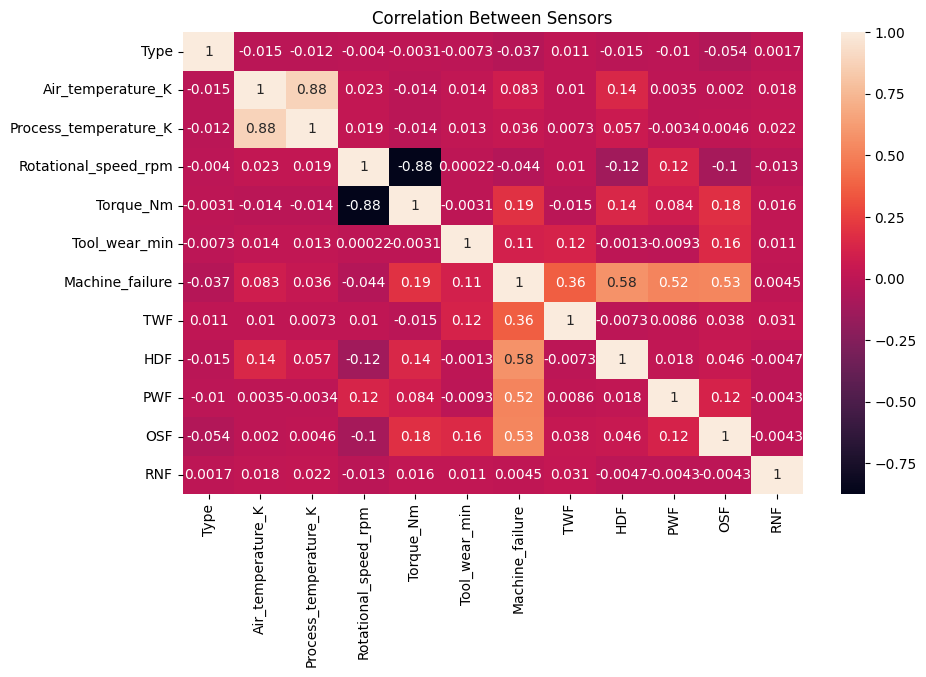

In [53]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Between Sensors")
plt.show()

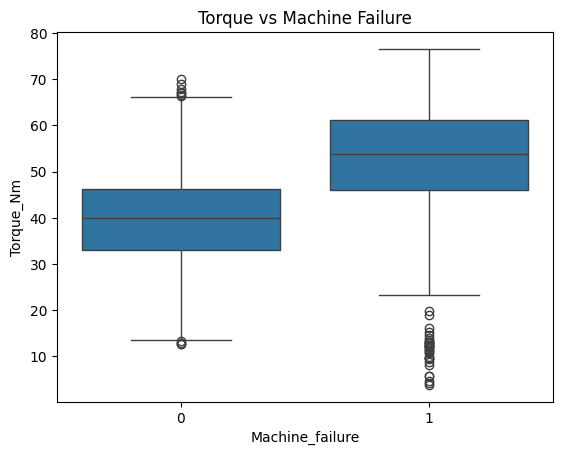

In [54]:
#Sensor VS Machine Failure
sns.boxplot(x="Machine_failure", y="Torque_Nm", data=data)
plt.title("Torque vs Machine Failure")
plt.show()

In [56]:
#Feature Selection
X = data.drop("Machine_failure", axis=1)
y = data["Machine_failure"]

In [57]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [59]:
#Random Forest Model

#train model
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

#prediction
rf_pred = rf_model.predict(X_test)

#accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.999


In [60]:
#XG Boost Model

#Train Model
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

#prediction
xgb_pred = xgb_model.predict(X_test)

#accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.999


In [61]:
#Classification Report
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



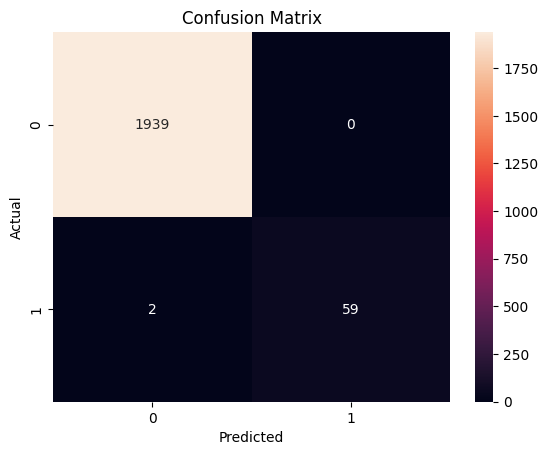

In [62]:
#Confusion matrix
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

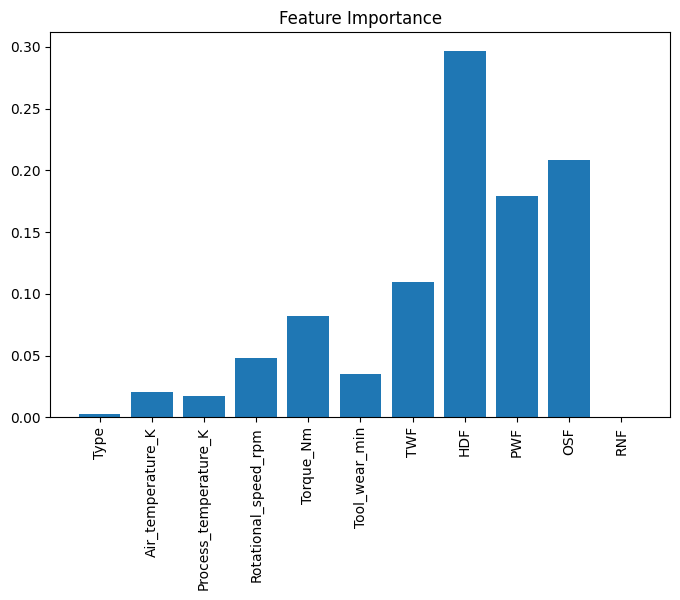

In [63]:
#Feature Importance
importance = rf_model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.show()


In [64]:
#LSTM Model
!pip install tensorflow

#Data Preprocessing
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

#Reshape for LSTM
X_lstm = np.reshape(X_scaled, (X_scaled.shape[0], X_scaled.shape[1], 1))

#Train Test Split
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
X_lstm, y, test_size=0.2, random_state=42
)

In [66]:
#Build LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(LSTM(50, input_shape=(X_train_lstm.shape[1],1)))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [68]:
#Train LSTM Model
lstm_model.fit(X_train_lstm,y_train_lstm,epochs=10,batch_size=32)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9991 - loss: 0.0083
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0074
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0093
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9985 - loss: 0.0129
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9994 - loss: 0.0060
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9993 - loss: 0.0069
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9990 - loss: 0.0083
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9993 - loss: 0.0057
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9992 - loss: 0.0064
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9996 - loss: 0.0037


In [69]:
loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test_lstm)

print("LSTM Accuracy:", lstm_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9975 - loss: 0.0210
LSTM Accuracy: 0.9990000128746033


In [70]:
with open("README.md", "w") as f:
    f.write("""
# Predictive Maintenance for Manufacturing using Machine Learning

## Project Overview
Predictive maintenance helps industries detect machine failures before they occur.
This project uses machine learning and deep learning models to predict machine failure using industrial sensor data.

## Dataset
The dataset contains machine sensor information such as:
- Air Temperature
- Process Temperature
- Rotational Speed
- Torque
- Tool Wear
- Machine Failure (Target Variable)

## Workflow
1. Data Cleaning
2. Exploratory Data Analysis
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. Model Comparison

## Models Used
- Random Forest
- XGBoost
- LSTM Neural Network

## Technologies
- Python
- Pandas
- Scikit-learn
- XGBoost
- TensorFlow
- Matplotlib
- Seaborn

## Results
XGBoost achieved the best accuracy in predicting machine failures.

## Author
Machine Learning Project
""")

In [71]:
from google.colab import files
files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>